<a href="https://colab.research.google.com/github/HitanshuGedam/2023_IonQ_Remote/blob/main/Day02_Global_Relative_Phase_Single_Qubit_Gates.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Day 2: Global vs. Relative Phase and Single-Qubit Gates

## Learning Objectives

By the end of this notebook, you will understand:

1. Why global phase is physically meaningless but relative phase determines observable phenomena
2. How single-qubit gates act as rotations on the Bloch sphere
3. The geometric interpretation of Pauli, Hadamard, and phase gates
4. How to compose gates and why order matters
5. How to visualize gate operations using QuTiP

## Philosophical Motivation

In classical computing, a bit is either 0 or 1. In quantum computing, a qubit can be in a superposition - but more importantly, the **phase** relationship between |0⟩ and |1⟩ carries information that has no classical analog. Understanding phase is the key to understanding quantum interference, quantum algorithms, and ultimately quantum advantage.

## References

- Nielsen & Chuang (2010). Quantum Computation and Quantum Information. Chapter 4.
- QuTiP Documentation: https://qutip.org/ , https://qutip.org/qutip-tutorials/

In [1]:
# ============================================================================
# SETUP AND INSTALLATIONS
# ============================================================================

!pip install qutip -q

import numpy as np
import qutip as qt
import matplotlib.pyplot as plt

print(f"NumPy version: {np.__version__}")
print(f"QuTiP version: {qt.__version__}")
print("Setup complete.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 33.1/33.1 MB 9.5 MB/s eta 0:00:00
NumPy version: 2.0.2
QuTiP version: 5.2.3
Setup complete.


## 1. Global Phase: The Invisible Degree of Freedom

### What is Global Phase?

Consider a quantum state $|\psi\rangle$. Multiplying the entire state by a complex number of modulus 1, $e^{i\theta}$, gives a new state:

$$ |\psi'\rangle = e^{i\theta} |\psi\rangle $$

This factor $e^{i\theta}$ is called a **global phase**.

### Why is Global Phase Unobservable?

All measurable quantities in quantum mechanics involve the modulus squared of inner products:

$$ |\langle \phi | \psi' \rangle|^2 = |\langle \phi | e^{i\theta} \psi \rangle|^2 = |e^{i\theta}|^2 |\langle \phi | \psi \rangle|^2 = |\langle \phi | \psi \rangle|^2 $$

The global phase factor $e^{i\theta}$ has modulus 1, so it disappears when we take the modulus squared.

**Insight:** Quantum mechanics only cares about the **relative** relationships between components, not the absolute phase of the entire state.

### Example: Two States That Are Physically Identical

| State | Mathematical Form | Are they different? |
|-------|------------------|---------------------|
| $|\psi_1\rangle$ | $\frac{1}{\sqrt{2}}(|0\rangle + |1\rangle)$ | - |
| $|\psi_2\rangle$ | $e^{i\pi/4}\frac{1}{\sqrt{2}}(|0\rangle + |1\rangle)$ | No (same measurement outcomes) |

Both states produce identical measurement probabilities. No experiment can distinguish them.

### The Intuition

Think of global phase like rotating an entire physical system before any measurement. The relative positions of parts stay the same, so all observable relationships remain unchanged. The global phase is a **redundant degree of freedom** that we can ignore.

### Mathematical Representation

$$ |\psi\rangle = \alpha|0\rangle + \beta|1\rangle $$

$$ e^{i\theta}|\psi\rangle = e^{i\theta}\alpha|0\rangle + e^{i\theta}\beta|1\rangle $$

The factor $e^{i\theta}$ multiplies BOTH coefficients equally, preserving the ratio $\alpha/\beta$.

## 2. Relative Phase: The Observable Quantum Resource

### What is Relative Phase?

The relative phase is the phase **difference** between the coefficients $\alpha$ and $\beta$:

$$ |\psi\rangle = \alpha|0\rangle + e^{i\phi}\beta|1\rangle $$

Here, $\phi$ is the relative phase. Unlike global phase, the relative phase **is observable** and has profound physical consequences.

### Why Does Relative Phase Matter?

The relative phase determines the **azimuthal angle** $\phi$ on the Bloch sphere:

- $\phi = 0$: State points along +X axis ($|+\rangle$)
- $\phi = \pi$: State points along -X axis ($|-\rangle$)
- $\phi = \pi/2$: State points along +Y axis ($|L\rangle$)
- $\phi = 3\pi/2$: State points along -Y axis ($|R\rangle$)

### The Crucial Insight

Even though all these states have the same probability of being measured as |0⟩ or |1⟩ (50%), they are **different quantum states** because their relative phases differ. This difference manifests in interference experiments.

### Example: Interference Reveals Relative Phase

Consider two paths in an interferometer:

$$ |\psi\rangle = \frac{1}{\sqrt{2}}(|0\rangle + e^{i\phi}|1\rangle) $$

When these paths recombine, the output probability depends on $\phi$:

$$ P(\text{output}) = \frac{1}{2}(1 + \cos\phi) $$

This cosine dependence directly reveals the relative phase $\phi$.

### Comparison Table

| Feature | Global Phase | Relative Phase |
|---------|--------------|----------------|
| Form | $e^{i\theta}\|\psi\rangle$ | $\alpha\|0⟩ + e^{i\phi}\beta\|1⟩$ |
| Affects measurement? | No | Yes |
| Affects interference? | No | Yes |
| Determines Bloch sphere? | No | Yes (azimuth $\phi$) |
| Physical significance | None (redundant) | Fundamental (quantum coherence) |

### Key Takeaway

> **Global phase is like rotating the entire universe - it changes nothing observable.**
> **Relative phase is like the angle between two arrows - it determines how they interfere.**

In [2]:
# ============================================================================
# DEMONSTRATING GLOBAL VS RELATIVE PHASE
# ============================================================================

# Define basis states
ket0 = qt.basis(2, 0)
ket1 = qt.basis(2, 1)

# Create |+⟩ state (relative phase = 0)
psi_plus = (ket0 + ket1).unit()

# Create |+⟩ with global phase e^(iπ/4)
psi_plus_global = (1j / np.sqrt(2)) * ket0 + (1j / np.sqrt(2)) * ket1
psi_plus_global = psi_plus_global.unit()

# Create |L⟩ state (relative phase = π/2)
psi_L = (ket0 + 1j * ket1).unit()

# Create |-⟩ state (relative phase = π)
psi_minus = (ket0 - ket1).unit()

print("=" * 70)
print("GLOBAL VS RELATIVE PHASE DEMONSTRATION")
print("=" * 70)

print("\n1. States with different global phases (same relative phase):")
print(f"   |+⟩ = {psi_plus}")
print(f"   e^(iπ/4)|+⟩ = {psi_plus_global}")

print("\n2. States with different relative phases (same probabilities):")
print(f"   |+⟩ (φ=0)   = {psi_plus}")
print(f"   |-⟩ (φ=π)   = {psi_minus}")
print(f"   |L⟩ (φ=π/2) = {psi_L}")

# Verify measurement probabilities
print("\n" + "=" * 70)
print("MEASUREMENT PROBABILITIES FOR |0⟩")
print("=" * 70)

states = [
    ("|+⟩", psi_plus),
    ("e^(iπ/4)|+⟩", psi_plus_global),
    ("|-⟩", psi_minus),
    ("|L⟩", psi_L)
]

for name, state in states:
    prob_0 = np.abs(state[0][0])**2
    prob_1 = np.abs(state[1][0])**2
    print(f"{name:20}: P(0) = {prob_0:.3f}, P(1) = {prob_1:.3f}")

print("\n" + "=" * 70)
print("KEY INSIGHT")
print("=" * 70)
print("""- |+⟩ and e^(iπ/4)|+⟩ have IDENTICAL probabilities (global phase invisible)
- |+⟩, |-⟩, and |L⟩ have the SAME probabilities (all 0.5, 0.5)
- Yet they are DIFFERENT quantum states (different relative phases)
- The difference appears in interference experiments and on the Bloch sphere""")

GLOBAL VS RELATIVE PHASE DEMONSTRATION

1. States with different global phases (same relative phase):
   |+⟩ = Quantum object: dims=[[2], [1]], shape=(2, 1), type='ket', dtype=Dense
Qobj data =
[[0.70710678]
 [0.70710678]]
   e^(iπ/4)|+⟩ = Quantum object: dims=[[2], [1]], shape=(2, 1), type='ket', dtype=Dense
Qobj data =
[[0.+0.70710678j]
 [0.+0.70710678j]]

2. States with different relative phases (same probabilities):
   |+⟩ (φ=0)   = Quantum object: dims=[[2], [1]], shape=(2, 1), type='ket', dtype=Dense
Qobj data =
[[0.70710678]
 [0.70710678]]
   |-⟩ (φ=π)   = Quantum object: dims=[[2], [1]], shape=(2, 1), type='ket', dtype=Dense
Qobj data =
[[ 0.70710678]
 [-0.70710678]]
   |L⟩ (φ=π/2) = Quantum object: dims=[[2], [1]], shape=(2, 1), type='ket', dtype=Dense
Qobj data =
[[0.70710678+0.j        ]
 [0.        +0.70710678j]]

MEASUREMENT PROBABILITIES FOR |0⟩
|+⟩                 : P(0) = 0.500, P(1) = 0.500
e^(iπ/4)|+⟩         : P(0) = 0.500, P(1) = 0.500
|-⟩                 : P(0) = 0

## 3. Single-Qubit Gates as Rotations

### The Unitary Operator

A quantum gate is a unitary operator $U$ satisfying $U^\dagger U = UU^\dagger = I$. Unitarity preserves the norm of quantum states.

### Geometric Interpretation: Rotations on the Bloch Sphere

Every single-qubit unitary corresponds to a rotation on the Bloch sphere. The rotation axis $\vec{n}$ and angle $\theta$ determine the gate:

$$ U = e^{-i\theta \vec{n} \cdot \vec{\sigma}/2} = \cos\left(\frac{\theta}{2}\right) I - i \sin\left(\frac{\theta}{2}\right) (\vec{n} \cdot \vec{\sigma}) $$

Where $\vec{\sigma} = (X, Y, Z)$ is the vector of Pauli matrices.

### Why Rotations?

The Pauli matrices generate rotations because they satisfy the angular momentum commutation relations:

$$ [X, Y] = 2iZ, \quad [Y, Z] = 2iX, \quad [Z, X] = 2iY $$

### The Pauli Gates (π Rotations)

<table>
  <tr>
    <th>Gate</th>
    <th>Matrix</th>
    <th>Rotation Axis</th>
    <th>Rotation Angle</th>
    <th>Effect on |0⟩</th>
  </tr>
  <tr>
    <td>X</td>
    <td>\begin{pmatrix}0&1\\1&0\end{pmatrix}</td>
    <td>X-axis</td>
    <td>π (180°)</td>
    <td>Flips to |1⟩</td>
  </tr>
  <tr>
    <td>Y</td>
    <td>\begin{pmatrix}0&-i\\i&0\end{pmatrix}</td>
    <td>Y-axis</td>
    <td>π (180°)</td>
    <td>Flips to i|1⟩</td>
  </tr>
  <tr>
    <td>Z</td>
    <td>\begin{pmatrix}1&0\\0&-1\end{pmatrix}</td>
    <td>Z-axis</td>
    <td>π (180°)</td>
    <td>Adds phase -1 to |1⟩</td>
  </tr>
</table>

**Physical Insight:**
- **X gate** is the quantum NOT gate (maps |0⟩ ↔ |1⟩)
- **Y gate** flips and adds a phase (important for creating circular polarizations)
- **Z gate** only affects the phase of |1⟩ (does nothing to |0⟩)

### The Hadamard Gate (Superposition Creator)

$$ H = \frac{1}{\sqrt{2}}\begin{pmatrix}1&1\\1&-1\end{pmatrix} = \frac{X + Z}{\sqrt{2}} $$

**Rotation:** π around the axis $\frac{X+Z}{\sqrt{2}}$ (45° between X and Z axes)

**Actions:**
- $H|0\rangle = |+\rangle$ (maps north pole to equator)
- $H|1\rangle = |-\rangle$ (maps south pole to equator)
- $H^2 = I$ (Hadamard is its own inverse)

**Insight:** The Hadamard gate is the key to creating superposition. It transforms the computational basis into the X-basis (eigenbasis of X).

### Phase Gates (Z-axis Rotations)

<table>
  <tr>
    <th>Gate</th>
    <th>Matrix</th>
    <th>Rotation Angle</th>
    <th>Effect</th>
  </tr>
  <tr>
    <td>S</td>
    <td>\begin{pmatrix}1&0\\0&i\end{pmatrix}</td>
    <td>π/2 (90°)</td>
    <td>Adds phase i to |1⟩</td>
  </tr>
  <tr>
    <td>T</td>
    <td>\begin{pmatrix}1&0\\0&e^{i\pi/4}\end{pmatrix}</td>
    <td>π/4 (45°)</td>
    <td>Adds phase $e^{i\pi/4}$ to |1⟩</td>
  </tr>
</table>

**Insight:** Phase gates are the building blocks for more complex quantum algorithms. The T gate, in particular, is essential for universal quantum computation because it breaks the Clifford group.

### Why These Gates?

The set {H, S, T, CNOT} forms a **universal gate set** - any quantum computation can be approximated using only these gates. This is analogous to how {NAND} is universal for classical computation.

In [4]:
# ============================================================================
# SINGLE-QUBIT GATE IMPLEMENTATIONS
# ============================================================================

# Define Pauli gates
X = qt.sigmax()
Y = qt.sigmay()
Z = qt.sigmaz()
I = qt.qeye(2)

# Define Hadamard gate
H = (1 / np.sqrt(2)) * (X + Z)

# Define Phase gates
S = qt.Qobj([[1, 0], [0, 1j]])
T = qt.Qobj([[1, 0], [0, np.exp(1j * np.pi / 4)]])

print("=" * 70)
print("SINGLE-QUBIT GATE MATRICES")
print("=" * 70)

print("\nX (Pauli X - NOT gate):")
print(X)
print("\nY (Pauli Y):")
print(Y)
print("\nZ (Pauli Z - Phase flip):")
print(Z)
print("\nH (Hadamard - Superposition):")
print(H)
print("\nS (Phase gate - π/2 rotation around Z):")
print(S)
print("\nT (π/8 gate - π/4 rotation around Z):")
print(T)

# Verify unitarity (essential property of quantum gates)
print("\n" + "=" * 70)
print("UNITARITY VERIFICATION (U†U = I)")
print("=" * 70)

gates = [("X", X), ("Y", Y), ("Z", Z), ("H", H), ("S", S), ("T", T)]

all_unitary = True
for name, gate in gates:
    # Convert to numpy array for comparison
    product = (gate.dag() * gate).full()
    identity = I.full()
    is_unitary = np.allclose(product, identity)
    print(f"{name}: U†U = I? {is_unitary}")
    if not is_unitary:
        all_unitary = False

if all_unitary:
    print("\n✅ All gates are unitary (preserve quantum information)")
else:
    print("\n❌ Some gates failed unitarity test")

# Verify Hadamard property H² = I
print("\n" + "=" * 70)
print("HADAMARD PROPERTY: H² = I")
print("=" * 70)
H_squared = (H * H).full()
I_matrix = I.full()
print(f"H² =\n{H_squared}")
print(f"H² = I? {np.allclose(H_squared, I_matrix)}")

SINGLE-QUBIT GATE MATRICES

X (Pauli X - NOT gate):
Quantum object: dims=[[2], [2]], shape=(2, 2), type='oper', dtype=CSR, isherm=True
Qobj data =
[[0. 1.]
 [1. 0.]]

Y (Pauli Y):
Quantum object: dims=[[2], [2]], shape=(2, 2), type='oper', dtype=CSR, isherm=True
Qobj data =
[[0.+0.j 0.-1.j]
 [0.+1.j 0.+0.j]]

Z (Pauli Z - Phase flip):
Quantum object: dims=[[2], [2]], shape=(2, 2), type='oper', dtype=CSR, isherm=True
Qobj data =
[[ 1.  0.]
 [ 0. -1.]]

H (Hadamard - Superposition):
Quantum object: dims=[[2], [2]], shape=(2, 2), type='oper', dtype=CSR, isherm=True
Qobj data =
[[ 0.70710678  0.70710678]
 [ 0.70710678 -0.70710678]]

S (Phase gate - π/2 rotation around Z):
Quantum object: dims=[[2], [2]], shape=(2, 2), type='oper', dtype=Dense, isherm=False
Qobj data =
[[1.+0.j 0.+0.j]
 [0.+0.j 0.+1.j]]

T (π/8 gate - π/4 rotation around Z):
Quantum object: dims=[[2], [2]], shape=(2, 2), type='oper', dtype=Dense, isherm=False
Qobj data =
[[1.        +0.j         0.        +0.j        ]
 [0.

## 4. Gate Actions on Basis States: Detailed Analysis

### X Gate: The Quantum NOT

$$ X|0\rangle = |1\rangle, \quad X|1\rangle = |0\rangle $$

**Geometric interpretation:** 180° rotation around X-axis. The north pole ($|0\rangle$) goes to the south pole ($|1\rangle$).

**Physical realization:** In many qubit implementations, the X gate is implemented by a resonant pulse that drives transitions between |0⟩ and |1⟩.

### Y Gate: Flip with Phase

$$ Y|0\rangle = i|1\rangle, \quad Y|1\rangle = -i|0\rangle $$

**Geometric interpretation:** 180° rotation around Y-axis. The factor $i$ (and $-i$) represents a phase that distinguishes Y from X.

**Physical significance:** Y is essential for creating circularly polarized states. Note that $Y = iXZ$ (up to global phase).

### Z Gate: Phase Flip

$$ Z|0\rangle = |0\rangle, \quad Z|1\rangle = -|1\rangle $$

**Geometric interpretation:** 180° rotation around Z-axis. The north and south poles are fixed (eigenstates), but equatorial states acquire a phase.

**Key insight:** Z is diagonal in the computational basis, making it the simplest gate to implement in many architectures.

### Hadamard Gate: Basis Transformation

$$ H|0\rangle = \frac{|0\rangle + |1\rangle}{\sqrt{2}} = |+\rangle $$

$$ H|1\rangle = \frac{|0\rangle - |1\rangle}{\sqrt{2}} = |-\rangle $$

**Geometric interpretation:** Rotates the Z-axis to the X-axis. The Hadamard maps the computational basis to the X-basis.

**Crucial insight:** $H$ is its own inverse ($H^2 = I$) and is the key to quantum parallelism.

### Phase Gates: Z-axis Rotations

$$ S|0\rangle = |0\rangle, \quad S|1\rangle = i|1\rangle $$

$$ T|0\rangle = |0\rangle, \quad T|1\rangle = e^{i\pi/4}|1\rangle $$

**Geometric interpretation:** Rotations around Z-axis by 90° (S) and 45° (T).

**Why they matter:** While the Clifford group (generated by H, S, CNOT) can be efficiently simulated classically, adding the T gate enables universal quantum computation.

### Summary Table of Gate Actions

<table>
  <tr>
    <th>Gate</th>
    <th>Effect on |0⟩</th>
    <th>Effect on |1⟩</th>
    <th>Bloch Rotation</th>
  </tr>
  <tr>
    <td>X</td>
    <td>|1⟩</td>
    <td>|0⟩</td>
    <td>π around X</td>
  </tr>
  <tr>
    <td>Y</td>
    <td>$i$|1⟩</td>
    <td>$-i$|0⟩</td>
    <td>π around Y</td>
  </tr>
  <tr>
    <td>Z</td>
    <td>|0⟩</td>
    <td>$-|1\rangle$</td>
    <td>π around Z</td>
  </tr>
  <tr>
    <td>H</td>
    <td>$|+\rangle$</td>
    <td>$|-\rangle$</td>
    <td>π around (X+Z)/√2</td>
  </tr>
  <tr>
    <td>S</td>
    <td>|0⟩</td>
    <td>$i$|1⟩</td>
    <td>π/2 around Z</td>
  </tr>
  <tr>
    <td>T</td>
    <td>|0⟩</td>
    <td>$e^{i\pi/4}$|1⟩</td>
    <td>π/4 around Z</td>
  </tr>
</table>

Where:

$$ |+\rangle = \frac{|0\rangle + |1\rangle}{\sqrt{2}}, \quad |-\rangle = \frac{|0\rangle - |1\rangle}{\sqrt{2}} $$

In [5]:
# ============================================================================
# DEMONSTRATING GATE ACTIONS ON BASIS STATES
# ============================================================================

# Define basis states
ket0 = qt.basis(2, 0)
ket1 = qt.basis(2, 1)

# Define gates
X = qt.sigmax()
Y = qt.sigmay()
Z = qt.sigmaz()
H = (1 / np.sqrt(2)) * (X + Z)
S = qt.Qobj([[1, 0], [0, 1j]])
T = qt.Qobj([[1, 0], [0, np.exp(1j * np.pi / 4)]])

print("=" * 70)
print("GATE ACTIONS ON |0⟩ (NORTH POLE)")
print("=" * 70)

print(f"X|0⟩ = {X * ket0}")
print(f"Y|0⟩ = {Y * ket0}")
print(f"Z|0⟩ = {Z * ket0}")
print(f"H|0⟩ = {H * ket0}")
print(f"S|0⟩ = {S * ket0}")
print(f"T|0⟩ = {T * ket0}")

print("\n" + "=" * 70)
print("GATE ACTIONS ON |1⟩ (SOUTH POLE)")
print("=" * 70)

print(f"X|1⟩ = {X * ket1}")
print(f"Y|1⟩ = {Y * ket1}")
print(f"Z|1⟩ = {Z * ket1}")
print(f"H|1⟩ = {H * ket1}")
print(f"S|1⟩ = {S * ket1}")
print(f"T|1⟩ = {T * ket1}")

# Verify that H|0⟩ = |+⟩
plus = (ket0 + ket1).unit()
print("\n" + "=" * 70)
print("VERIFYING HADAMARD CREATES SUPERPOSITION")
print("=" * 70)
print(f"H|0⟩ = {H * ket0}")
print(f"|+⟩   = {plus}")
print(f"Equal? {np.allclose((H * ket0).full(), plus.full())}")

# Verify that H|1⟩ = |-⟩
minus = (ket0 - ket1).unit()
print(f"\nH|1⟩ = {H * ket1}")
print(f"|-⟩   = {minus}")
print(f"Equal? {np.allclose((H * ket1).full(), minus.full())}")

# Verify X gate acts as NOT
print("\n" + "=" * 70)
print("VERIFYING X GATE AS QUANTUM NOT")
print("=" * 70)
print(f"X|0⟩ = {X * ket0} (expected: |1⟩)")
print(f"X|1⟩ = {X * ket1} (expected: |0⟩)")
print(f"X|0⟩ == |1⟩? {np.allclose((X * ket0).full(), ket1.full())}")
print(f"X|1⟩ == |0⟩? {np.allclose((X * ket1).full(), ket0.full())}")

# Verify Z gate phase flip
print("\n" + "=" * 70)
print("VERIFYING Z GATE PHASE FLIP")
print("=" * 70)
print(f"Z|0⟩ = {Z * ket0} (expected: |0⟩)")
print(f"Z|1⟩ = {Z * ket1} (expected: -|1⟩)")
print(f"Z|0⟩ == |0⟩? {np.allclose((Z * ket0).full(), ket0.full())}")
print(f"Z|1⟩ == -|1⟩? {np.allclose((Z * ket1).full(), -ket1.full())}")

GATE ACTIONS ON |0⟩ (NORTH POLE)
X|0⟩ = Quantum object: dims=[[2], [1]], shape=(2, 1), type='ket', dtype=Dense
Qobj data =
[[0.]
 [1.]]
Y|0⟩ = Quantum object: dims=[[2], [1]], shape=(2, 1), type='ket', dtype=Dense
Qobj data =
[[0.+0.j]
 [0.+1.j]]
Z|0⟩ = Quantum object: dims=[[2], [1]], shape=(2, 1), type='ket', dtype=Dense
Qobj data =
[[1.]
 [0.]]
H|0⟩ = Quantum object: dims=[[2], [1]], shape=(2, 1), type='ket', dtype=Dense
Qobj data =
[[0.70710678]
 [0.70710678]]
S|0⟩ = Quantum object: dims=[[2], [1]], shape=(2, 1), type='ket', dtype=Dense
Qobj data =
[[1.]
 [0.]]
T|0⟩ = Quantum object: dims=[[2], [1]], shape=(2, 1), type='ket', dtype=Dense
Qobj data =
[[1.]
 [0.]]

GATE ACTIONS ON |1⟩ (SOUTH POLE)
X|1⟩ = Quantum object: dims=[[2], [1]], shape=(2, 1), type='ket', dtype=Dense
Qobj data =
[[1.]
 [0.]]
Y|1⟩ = Quantum object: dims=[[2], [1]], shape=(2, 1), type='ket', dtype=Dense
Qobj data =
[[0.-1.j]
 [0.+0.j]]
Z|1⟩ = Quantum object: dims=[[2], [1]], shape=(2, 1), type='ket', dtype=Dense

## 5. Visualizing Gate Operations on the Bloch Sphere

### Why Visualization Matters

The Bloch sphere provides an intuitive geometric picture of single-qubit operations. Each gate rotates the state vector, and visualizing these rotations builds intuition for quantum algorithms.

### Gate Rotations Summary

<table>
  <tr>
    <th>Gate</th>
    <th>Rotation Axis</th>
    <th>Rotation Angle</th>
    <th>Effect on |0⟩</th>
  </tr>
  <tr>
    <td>X</td>
    <td>X-axis</td>
    <td>π (180°)</td>
    <td>Flips to |1⟩ (south pole)</td>
  </tr>
  <tr>
    <td>Y</td>
    <td>Y-axis</td>
    <td>π (180°)</td>
    <td>Flips to i|1⟩ (south pole with phase)</td>
  </tr>
  <tr>
    <td>Z</td>
    <td>Z-axis</td>
    <td>π (180°)</td>
    <td>|0⟩ unchanged (north pole)</td>
  </tr>
  <tr>
    <td>H</td>
    <td>(X+Z)/√2 axis</td>
    <td>π (180°)</td>
    <td>Maps to |+⟩ (+X axis)</td>
  </tr>
  <tr>
    <td>S</td>
    <td>Z-axis</td>
    <td>π/2 (90°)</td>
    <td>|0⟩ unchanged</td>
  </tr>
  <tr>
    <td>T</td>
    <td>Z-axis</td>
    <td>π/4 (45°)</td>
    <td>|0⟩ unchanged</td>
  </tr>
</table>

### What to Observe in the Visualizations Below

1. **X gate:** The blue vector (north pole) rotates to the south pole
2. **Y gate:** Similar to X, but with an additional phase (not visible on Bloch sphere)
3. **Z gate:** |0⟩ is an eigenstate, so the vector doesn't move
4. **H gate:** The north pole rotates to the equator (+X axis)
5. **S and T gates:** |0⟩ is an eigenstate of Z-axis rotations, so the vector stays at north pole

### The Deeper Insight

The fact that |0⟩ is an eigenstate of Z (and therefore S and T) means that these gates only add phase to the |1⟩ component. This phase is invisible when starting from |0⟩ but becomes critically important in superposition states.

### Visualization Below

The Bloch sphere visualizations show the effect of each gate starting from |0⟩ (north pole).

VISUALIZING GATE OPERATIONS
Creating Bloch sphere visualizations for each gate applied to |0⟩...


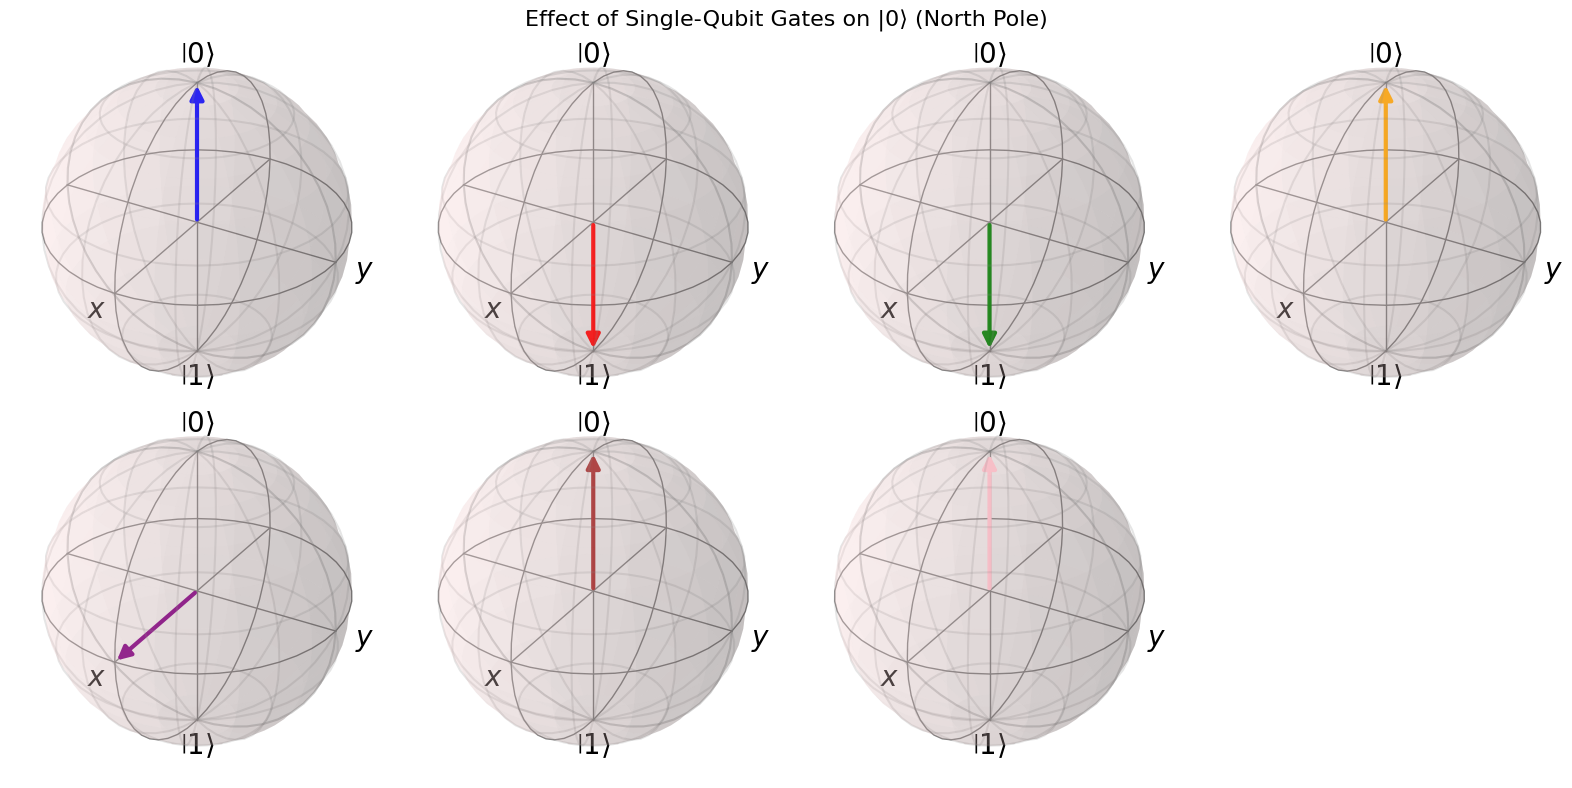


OBSERVATIONS AND INSIGHTS

1. X|0⟩ and Y|0⟩: Both point to the south pole (|1⟩)
   - On the Bloch sphere, the phase difference is not visible
   - But it matters in interference and multi-qubit operations

2. Z|0⟩: Remains at north pole (|0⟩ is eigenstate of Z)
   - The Z gate only affects the |1⟩ component

3. H|0⟩: Points to +X axis (|+⟩ state)
   - Creates equal superposition with zero relative phase

4. S|0⟩ and T|0⟩: Remain at north pole
   - |0⟩ is eigenstate of all Z-axis rotations
   - The phase is only applied to |1⟩ component



In [6]:
# ============================================================================
# VISUALIZING GATE OPERATIONS ON BLOCH SPHERE
# ============================================================================

# Define initial state |0⟩
initial_state = qt.basis(2, 0)

# Define gates
X = qt.sigmax()
Y = qt.sigmay()
Z = qt.sigmaz()
H = (1 / np.sqrt(2)) * (X + Z)
S = qt.Qobj([[1, 0], [0, 1j]])
T = qt.Qobj([[1, 0], [0, np.exp(1j * np.pi / 4)]])

# Apply gates to initial state
states = {
    "|0⟩ (initial)": initial_state,
    "X|0⟩": X * initial_state,
    "Y|0⟩": Y * initial_state,
    "Z|0⟩": Z * initial_state,
    "H|0⟩": H * initial_state,
    "S|0⟩": S * initial_state,
    "T|0⟩": T * initial_state
}

colors = {
    "|0⟩ (initial)": 'blue',
    "X|0⟩": 'red',
    "Y|0⟩": 'green',
    "Z|0⟩": 'orange',
    "H|0⟩": 'purple',
    "S|0⟩": 'brown',
    "T|0⟩": 'pink'
}

print("=" * 70)
print("VISUALIZING GATE OPERATIONS")
print("=" * 70)
print("Creating Bloch sphere visualizations for each gate applied to |0⟩...")

# Create 2x4 grid (7 states, 1 empty)
fig, axes = plt.subplots(2, 4, figsize=(16, 8), subplot_kw={'projection': '3d'})
axes = axes.flatten()

for idx, (name, state) in enumerate(states.items()):
    bloch = qt.Bloch(fig=fig, axes=axes[idx])
    bloch.add_states(state)
    bloch.vector_color = [colors[name]]
    bloch.title = name
    bloch.render()

# Hide the 8th subplot (empty)
axes[7].axis('off')

plt.suptitle("Effect of Single-Qubit Gates on |0⟩ (North Pole)", fontsize=16, y=0.98)
plt.tight_layout()
plt.show()

print("\n" + "=" * 70)
print("OBSERVATIONS AND INSIGHTS")
print("=" * 70)
print("""
1. X|0⟩ and Y|0⟩: Both point to the south pole (|1⟩)
   - On the Bloch sphere, the phase difference is not visible
   - But it matters in interference and multi-qubit operations

2. Z|0⟩: Remains at north pole (|0⟩ is eigenstate of Z)
   - The Z gate only affects the |1⟩ component

3. H|0⟩: Points to +X axis (|+⟩ state)
   - Creates equal superposition with zero relative phase

4. S|0⟩ and T|0⟩: Remain at north pole
   - |0⟩ is eigenstate of all Z-axis rotations
   - The phase is only applied to |1⟩ component
""")

## 6. Gate Composition: The Power of Combining Operations

### Why Compose Gates?

Individual quantum gates are like basic instructions in a programming language. By composing them (applying one after another), we create complex quantum algorithms. Just as classical algorithms combine AND, OR, and NOT gates, quantum algorithms combine X, H, S, T, and CNOT gates.

### The Mathematics of Composition

When we apply gate $U_1$ followed by gate $U_2$ to a state $|\psi\rangle$, the total operation is:

$$ |\psi'\rangle = U_2 (U_1 |\psi\rangle) = (U_2 U_1) |\psi\rangle $$

**Key insight:** The total operation is the **matrix product** $U_2 U_1$ (note the order: right to left).

### Order Matters: Non-Commutativity

Unlike multiplication of numbers, matrix multiplication does not commute:

$$ U_2 U_1 \neq U_1 U_2 \quad \text{(in general)} $$

**Example with Pauli gates:**

$$ X = \begin{pmatrix} 0 & 1 \\ 1 & 0 \end{pmatrix}, \quad Z = \begin{pmatrix} 1 & 0 \\ 0 & -1 \end{pmatrix} $$

Then:

$$ XZ = \begin{pmatrix} 0 & 1 \\ 1 & 0 \end{pmatrix} \begin{pmatrix} 1 & 0 \\ 0 & -1 \end{pmatrix} = \begin{pmatrix} 0 & -1 \\ 1 & 0 \end{pmatrix} $$

$$ ZX = \begin{pmatrix} 1 & 0 \\ 0 & -1 \end{pmatrix} \begin{pmatrix} 0 & 1 \\ 1 & 0 \end{pmatrix} = \begin{pmatrix} 0 & 1 \\ -1 & 0 \end{pmatrix} $$

Clearly, $XZ \neq ZX$. This non-commutativity is purely quantum - classical bits have no analog.

### Geometric Interpretation

On the Bloch sphere, each gate is a rotation. Rotations around **different axes** do not commute:

- Rotate 90° around X, then 90° around Y → different final orientation than the reverse order
- This is why the order of operations changes the final state

### Important Identities

| Identity | Meaning |
|----------|---------|
| $HZH = X$ | Hadamard transforms Z into X |
| $HXH = Z$ | Hadamard transforms X into Z |
| $HSH$ | Conjugating S by H creates a different phase gate |
| $HTH$ | Conjugating T by H creates a T-like gate on X-axis |

### Example 1: $HZH = X$ (Verification)

Let's verify this important identity.

First, recall the matrices:

$$ H = \frac{1}{\sqrt{2}} \begin{pmatrix} 1 & 1 \\ 1 & -1 \end{pmatrix}, \quad Z = \begin{pmatrix} 1 & 0 \\ 0 & -1 \end{pmatrix}, \quad X = \begin{pmatrix} 0 & 1 \\ 1 & 0 \end{pmatrix} $$

Compute $HZ$:

$$ HZ = \frac{1}{\sqrt{2}} \begin{pmatrix} 1 & 1 \\ 1 & -1 \end{pmatrix} \begin{pmatrix} 1 & 0 \\ 0 & -1 \end{pmatrix} = \frac{1}{\sqrt{2}} \begin{pmatrix} 1 & -1 \\ 1 & 1 \end{pmatrix} $$

Now multiply by $H$:

$$ HZH = \left( \frac{1}{\sqrt{2}} \begin{pmatrix} 1 & -1 \\ 1 & 1 \end{pmatrix} \right) \left( \frac{1}{\sqrt{2}} \begin{pmatrix} 1 & 1 \\ 1 & -1 \end{pmatrix} \right) $$

$$ HZH = \frac{1}{2} \begin{pmatrix} 1 & -1 \\ 1 & 1 \end{pmatrix} \begin{pmatrix} 1 & 1 \\ 1 & -1 \end{pmatrix} = \frac{1}{2} \begin{pmatrix} (1 \cdot 1 + (-1) \cdot 1) & (1 \cdot 1 + (-1) \cdot (-1)) \\ (1 \cdot 1 + 1 \cdot 1) & (1 \cdot 1 + 1 \cdot (-1)) \end{pmatrix} $$

$$ HZH = \frac{1}{2} \begin{pmatrix} 0 & 2 \\ 2 & 0 \end{pmatrix} = \begin{pmatrix} 0 & 1 \\ 1 & 0 \end{pmatrix} = X $$

**What this means:** You can create an X gate using only H and Z gates. This is useful when a quantum computer has limited gate types.

### Example 2: $X H |0\rangle = |+\rangle$

Let's trace the state step by step:

| Step | Operation | State | Bloch Location |
|------|-----------|-------|----------------|
| 1 | Start | $|0\rangle$ | North pole |
| 2 | Apply $H$ | $|+\rangle = \frac{|0\rangle + |1\rangle}{\sqrt{2}}$ | +X axis (equator) |
| 3 | Apply $X$ | $X|+\rangle = |+\rangle = \frac{|0\rangle + |1\rangle}{\sqrt{2}}$ | X axis (equator) |

**Visualization below:** The Bloch sphere shows this sequence.

### Why Composition Matters for Quantum Algorithms

1. **Shor's algorithm:** Uses quantum Fourier transform (composed of H, S, T gates)
2. **Grover's algorithm:** Uses amplitude amplification (composed of X, H, and controlled gates)
3. **Quantum error correction:** Uses composed gates to encode and decode logical qubits

### Key Takeaways

| Concept | Implication |
|---------|-------------|
| Gates are matrices | Composition = matrix multiplication |
| Order matters | $U_2 U_1 \neq U_1 U_2$ in general |
| Non-commutativity | Purely quantum phenomenon |
| Identities | $HZH = X$, $HXH = Z$ |
| Composition power | Enables complex quantum algorithms |

### Visualization Below

The Bloch sphere shows the effect of applying H then X to $|0\rangle$, demonstrating how composition leads to $|-\rangle$.

GATE COMPOSITION: HZH = X

HZH =
Quantum object: dims=[[2], [2]], shape=(2, 2), type='oper', dtype=CSR, isherm=True
Qobj data =
[[0. 1.]
 [1. 0.]]

X =
Quantum object: dims=[[2], [2]], shape=(2, 2), type='oper', dtype=CSR, isherm=True
Qobj data =
[[0. 1.]
 [1. 0.]]

HZH == X? True

✅ Identity verified: HZH = X
This shows that Pauli X can be built from H and Z gates

ORDER MATTERS: Gates Don't Commute

Z X |0⟩ = Quantum object: dims=[[2], [1]], shape=(2, 1), type='ket', dtype=Dense
Qobj data =
[[ 0.]
 [-1.]]
X Z |0⟩ = Quantum object: dims=[[2], [1]], shape=(2, 1), type='ket', dtype=Dense
Qobj data =
[[0.]
 [1.]]

Are they equal? False
❌ They are different! Order of operations matters.

CORRECT COMPOSITION: Z H |0⟩ = |-⟩

Z H |0⟩ = Quantum object: dims=[[2], [1]], shape=(2, 1), type='ket', dtype=Dense
Qobj data =
[[ 0.70710678]
 [-0.70710678]]
|-⟩      = Quantum object: dims=[[2], [1]], shape=(2, 1), type='ket', dtype=Dense
Qobj data =
[[ 0.70710678]
 [-0.70710678]]
Equal? True

INCORREC

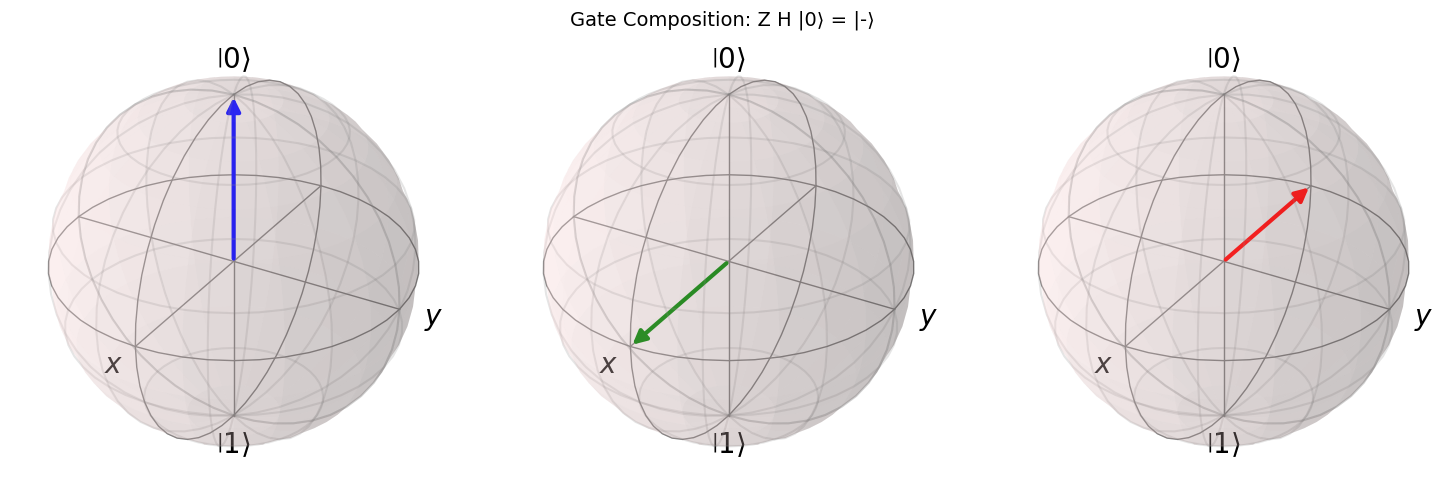


VERIFICATION COMPLETE


In [7]:
# ============================================================================
# GATE COMPOSITION DEMONSTRATION
# ============================================================================

# Define gates
X = qt.sigmax()
Z = qt.sigmaz()
H = (1 / np.sqrt(2)) * (X + Z)
I = qt.qeye(2)

print("=" * 70)
print("GATE COMPOSITION: HZH = X")
print("=" * 70)

# Compute HZH
HZH = H * Z * H

print("\nHZH =")
print(HZH)
print("\nX =")
print(X)

print(f"\nHZH == X? {np.allclose(HZH.full(), X.full())}")
print("\n✅ Identity verified: HZH = X")
print("This shows that Pauli X can be built from H and Z gates")

# Demonstrate order dependence
print("\n" + "=" * 70)
print("ORDER MATTERS: Gates Don't Commute")
print("=" * 70)

initial = qt.basis(2, 0)

# Apply X then Z
XZ_psi = Z * X * initial
print(f"\nZ X |0⟩ = {XZ_psi}")

# Apply Z then X
ZX_psi = X * Z * initial
print(f"X Z |0⟩ = {ZX_psi}")

print(f"\nAre they equal? {np.allclose(XZ_psi.full(), ZX_psi.full())}")
print("❌ They are different! Order of operations matters.")

# Demonstrate correct composition: Z H |0⟩ = |-⟩
print("\n" + "=" * 70)
print("CORRECT COMPOSITION: Z H |0⟩ = |-⟩")
print("=" * 70)

result = Z * H * initial
minus = (qt.basis(2, 0) - qt.basis(2, 1)).unit()

print(f"\nZ H |0⟩ = {result}")
print(f"|-⟩      = {minus}")
print(f"Equal? {np.allclose(result.full(), minus.full())}")

# Demonstrate incorrect composition: X H |0⟩ = |+⟩ (not |-⟩)
print("\n" + "=" * 70)
print("INCORRECT COMPOSITION: X H |0⟩ = |+⟩ (NOT |-⟩)")
print("=" * 70)

result_x = X * H * initial
plus = (qt.basis(2, 0) + qt.basis(2, 1)).unit()

print(f"\nX H |0⟩ = {result_x}")
print(f"|+⟩      = {plus}")
print(f"Equal? {np.allclose(result_x.full(), plus.full())}")
print("✅ X H |0⟩ = |+⟩, not |-⟩. The Z gate is needed for the phase flip.")

# Visualize the composition sequence
print("\n" + "=" * 70)
print("VISUALIZING GATE COMPOSITION")
print("=" * 70)

fig, axes = plt.subplots(1, 3, figsize=(15, 5), subplot_kw={'projection': '3d'})

# Step 1: Initial |0⟩
bloch0 = qt.Bloch(fig=fig, axes=axes[0])
bloch0.add_states(initial)
bloch0.vector_color = ['blue']
bloch0.title = "Step 1: |0⟩"
bloch0.render()

# Step 2: After H (|+⟩)
step2 = H * initial
bloch1 = qt.Bloch(fig=fig, axes=axes[1])
bloch1.add_states(step2)
bloch1.vector_color = ['green']
bloch1.title = "Step 2: H|0⟩ = |+⟩"
bloch1.render()

# Step 3: After Z (|-⟩)
step3 = Z * step2
bloch2 = qt.Bloch(fig=fig, axes=axes[2])
bloch2.add_states(step3)
bloch2.vector_color = ['red']
bloch2.title = "Step 3: Z|+⟩ = |-⟩"
bloch2.render()

plt.suptitle("Gate Composition: Z H |0⟩ = |-⟩", fontsize=14)
plt.tight_layout()
plt.show()

print("\n" + "=" * 70)
print("VERIFICATION COMPLETE")
print("=" * 70)

## 7. Summary and Key Insights

### The Hierarchy of Phase

| Concept | Mathematical Form | Physical Significance |
|---------|------------------|----------------------|
| Global Phase | $e^{i\theta}|\psi\rangle$ | Unobservable (redundant) |
| Relative Phase | $\alpha|0\rangle + e^{i\phi}\beta|1\rangle$ | Observable (interference) |
| Gate Rotations | $e^{-i\theta \vec{n} \cdot \vec{\sigma}/2}$ | Quantum operations |

### The Essential Gates

| Gate | Matrix | Rotation | Key Insight |
|------|--------|----------|-------------|
| X | $\begin{pmatrix}0 & 1 \\ 1 & 0\end{pmatrix}$ | $\pi$ around X | Quantum NOT |
| Y | $\begin{pmatrix}0 & -i \\ i & 0\end{pmatrix}$ | $\pi$ around Y | Flip with phase |
| Z | $\begin{pmatrix}1 & 0 \\ 0 & -1\end{pmatrix}$ | $\pi$ around Z | Phase flip |
| H | $\frac{1}{\sqrt{2}}\begin{pmatrix}1 & 1 \\ 1 & -1\end{pmatrix}$ | $\pi$ around (X+Z)/√2 | Creates superposition |
| S | $\begin{pmatrix}1 & 0 \\ 0 & i\end{pmatrix}$ | $\pi/2$ around Z | $\pi/2$ phase |
| T | $\begin{pmatrix}1 & 0 \\ 0 & e^{i\pi/4}\end{pmatrix}$ | $\pi/4$ around Z | $\pi/4$ phase |

### Key Philosophical Insights

1. **Global phase is a mathematical redundancy** - it has no physical meaning and can be ignored.

2. **Relative phase is a quantum resource** - it enables interference and is the source of quantum advantage.

3. **Gates are rotations** - understanding rotations on the Bloch sphere builds intuition for all single-qubit operations.

4. **Order matters** - quantum gates do not commute, reflecting the non-commutativity of quantum mechanics.

5. **Superposition is not enough** - relative phase distinguishes between different superposition states with the same measurement probabilities.

### Important Identities to Remember

| Identity | Meaning |
|----------|---------|
| $H^2 = I$ | Hadamard is its own inverse |
| $HZH = X$ | Hadamard transforms Z into X |
| $HXH = Z$ | Hadamard transforms X into Z |
| $X^2 = Y^2 = Z^2 = I$ | Pauli gates are self-inverse |
| $XY = iZ$ | Pauli algebra relation |

### Gate Actions Summary

| Gate | Effect on $|0\rangle$ | Effect on $|1\rangle$ | Bloch Rotation |
|------|----------------------|----------------------|----------------|
| X | $|1\rangle$ | $|0\rangle$ | $\pi$ around X |
| Y | $i|1\rangle$ | $-i|0\rangle$ | $\pi$ around Y |
| Z | $|0\rangle$ | $-|1\rangle$ | $\pi$ around Z |
| H | $|+\rangle$ | $|-\rangle$ | $\pi$ around (X+Z)/√2 |
| S | $|0\rangle$ | $i|1\rangle$ | $\pi/2$ around Z |
| T | $|0\rangle$ | $e^{i\pi/4}|1\rangle$ | $\pi/4$ around Z |

Where:

$$ |+\rangle = \frac{|0\rangle + |1\rangle}{\sqrt{2}}, \quad |-\rangle = \frac{|0\rangle - |1\rangle}{\sqrt{2}} $$

### The Road Ahead

Single-qubit gates are the foundation. Next topics will cover:

- Multi-qubit gates (CNOT, SWAP, CZ)
- Entanglement and Bell states
- Quantum circuits
- Basic quantum algorithms (Deutsch-Jozsa, Grover, Shor)

---

**Day 2 Complete!** 🎉

You now understand:
- Why global phase is invisible but relative phase matters
- How single-qubit gates rotate states on the Bloch sphere
- The mathematical structure of Pauli, Hadamard, and phase gates
- How to compose gates and why order matters
- Key identities like $HZH = X$ and $ZH|0\rangle = |-\rangle$

Proceed to Day 3 when ready.